In [2]:
!pip install -q ultralytics opencv-python matplotlib pandas numpy scikit-learn pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.1 MB/s eta 0:00:00


In [3]:
import torch
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: 8.4.164
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
!pip install -q --upgrade kaggle==2.2.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.6 MB/s eta 0:00:00


In [5]:
!kaggle --version

Kaggle CLI 2.2.2


In [6]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [7]:
!kaggle competitions list | head

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [8]:
!mkdir -p /content/severstal
!kaggle competitions download -c severstal-steel-defect-detection -p /content/severstal

100% 1.57G/1.57G [00:19<00:00, 86.3MB/s]



In [9]:
!mkdir -p /content/severstal/data
!unzip -q /content/severstal/severstal-steel-defect-detection.zip -d /content/severstal/data

In [10]:
!ls -lh /content/severstal/data

total 18M
-rw-r--r-- 1 root root 135K Dec 11  2019 sample_submission.csv
drwxr-xr-x 2 root root 200K Sep 28 08:55 test_images
-rw-r--r-- 1 root root  17M Dec 11  2019 train.csv
drwxr-xr-x 2 root root 460K Sep 28 08:55 train_images


In [13]:
import pandas as pd
import os

data_dir = "/content/severstal/data"

train_csv = os.path.join(data_dir, "train.csv")

df = pd.read_csv(train_csv)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

Shape: (7095, 3)

Columns:
['ImageId', 'ClassId', 'EncodedPixels']

First 10 rows:


,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
5,0025bde0c.jpg,3,8458 14 8707 35 8963 48 9219 71 9475 88 9731 8...
6,0025bde0c.jpg,4,315139 8 315395 15 315651 16 315906 17 316162 ...
7,002af848d.jpg,4,290800 6 291055 13 291311 15 291566 18 291822 ...
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


In [15]:
print("Defect classes:")
print(df["ClassId"].value_counts().sort_index())

Defect classes:
ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64


In [16]:
print("Unique defect images:", df["ImageId"].nunique())

print("\nImages by defect class:")
print(
    df.groupby("ClassId")["ImageId"]
      .nunique()
      .sort_index()
)

Unique defect images: 6666

Images by defect class:
ClassId
1     897
2     247
3    5150
4     801
Name: ImageId, dtype: int64


Image: 0002cc93b.jpg
Class: 1
Image shape: (256, 1600, 3)
Defect pixels: 4396
Defect area %: 1.0732421875


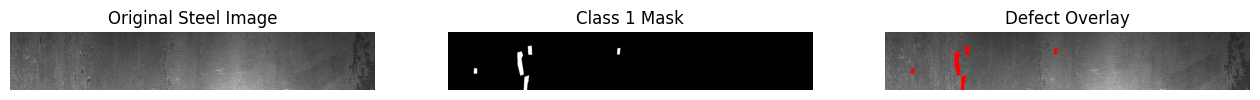

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Pick the first annotated defect
row = df.iloc[0]

image_id = row["ImageId"]
class_id = int(row["ClassId"])
rle = row["EncodedPixels"]

image_path = os.path.join(
    "/content/severstal/data/train_images",
    image_id
)

# Read image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image:", image_id)
print("Class:", class_id)
print("Image shape:", image.shape)

# RLE decoder
def rle_decode(rle, shape):
    s = np.asarray(rle.split(), dtype=int)
    starts = s[0::2] - 1
    lengths = s[1::2]
    ends = starts + lengths

    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for start, end in zip(starts, ends):
        mask[start:end] = 1

    return mask.reshape(shape, order="F")

mask = rle_decode(rle, image.shape[:2])

print("Defect pixels:", mask.sum())
print("Defect area %:", mask.mean() * 100)

# Create overlay
overlay = image.copy()
overlay[mask == 1] = [255, 0, 0]

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Steel Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title(f"Class {class_id} Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Defect Overlay")
plt.axis("off")

plt.show()

In [18]:
import os
import cv2
import shutil
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# -----------------------------
# Paths
# -----------------------------
DATA_DIR = "/content/severstal/data"
IMAGE_DIR = os.path.join(DATA_DIR, "train_images")

YOLO_DIR = "/content/steel_yolo"

# Remove old conversion if it exists
if os.path.exists(YOLO_DIR):
    shutil.rmtree(YOLO_DIR)

for split in ["train", "val"]:
    os.makedirs(os.path.join(YOLO_DIR, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DIR, "labels", split), exist_ok=True)

# -----------------------------
# Load annotation data
# -----------------------------
df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

# All available images
all_images = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith(".jpg")
])

# Images containing at least one defect
defect_images = set(df["ImageId"].unique())

# Clean images = no annotation in train.csv
clean_images = [
    f for f in all_images
    if f not in defect_images
]

print("Total images:", len(all_images))
print("Defect images:", len(defect_images))
print("Clean images:", len(clean_images))

# -----------------------------
# Select dataset
# -----------------------------
random.seed(42)

# Keep all defective images
selected_defect = list(defect_images)

# Add clean images until we reach ~8000
remaining = 8000 - len(selected_defect)

if remaining > 0:
    selected_clean = random.sample(
        clean_images,
        min(remaining, len(clean_images))
    )
else:
    selected_clean = []

selected_images = selected_defect + selected_clean
random.shuffle(selected_images)

print("Selected images:", len(selected_images))

# -----------------------------
# Train / validation split
# -----------------------------
train_images, val_images = train_test_split(
    selected_images,
    test_size=0.20,
    random_state=42
)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))

# -----------------------------
# RLE decoder
# -----------------------------
def rle_decode(rle, shape):
    s = np.asarray(rle.split(), dtype=int)

    starts = s[0::2] - 1
    lengths = s[1::2]
    ends = starts + lengths

    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for start, end in zip(starts, ends):
        mask[start:end] = 1

    return mask.reshape(shape, order="F")


# -----------------------------
# Convert one image to YOLO label
# -----------------------------
def create_yolo_label(image_id, rows, label_path):

    image_path = os.path.join(IMAGE_DIR, image_id)

    image = cv2.imread(image_path)

    if image is None:
        return

    h, w = image.shape[:2]

    label_lines = []

    for _, row in rows.iterrows():

        class_id = int(row["ClassId"]) - 1  # YOLO classes = 0,1,2,3

        rle = row["EncodedPixels"]

        if pd.isna(rle):
            continue

        mask = rle_decode(rle, (h, w))

        # Find separate defect regions
        contours, _ = cv2.findContours(
            mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        for contour in contours:

            # Ignore extremely tiny regions
            if cv2.contourArea(contour) < 3:
                continue

            # Simplify contour
            epsilon = 0.001 * cv2.arcLength(contour, True)

            polygon = cv2.approxPolyDP(
                contour,
                epsilon,
                True
            )

            if len(polygon) < 3:
                continue

            points = polygon.reshape(-1, 2)

            # Normalize x and y to 0-1
            normalized = []

            for x, y in points:
                normalized.append(x / w)
                normalized.append(y / h)

            label_line = (
                str(class_id) + " " +
                " ".join(f"{p:.6f}" for p in normalized)
            )

            label_lines.append(label_line)

    with open(label_path, "w") as f:
        f.write("\n".join(label_lines))


# -----------------------------
# Annotation lookup
# -----------------------------
annotation_groups = {
    image_id: group
    for image_id, group in df.groupby("ImageId")
}


# -----------------------------
# Process dataset
# -----------------------------
def process_split(image_list, split):

    for image_id in tqdm(
        image_list,
        desc=f"Processing {split}"
    ):

        # Copy image
        src = os.path.join(IMAGE_DIR, image_id)

        dst = os.path.join(
            YOLO_DIR,
            "images",
            split,
            image_id
        )

        shutil.copy2(src, dst)

        # Create label
        label_name = os.path.splitext(image_id)[0] + ".txt"

        label_path = os.path.join(
            YOLO_DIR,
            "labels",
            split,
            label_name
        )

        rows = annotation_groups.get(image_id)

        if rows is not None:
            create_yolo_label(
                image_id,
                rows,
                label_path
            )
        else:
            # Clean image → empty YOLO label
            open(label_path, "w").close()


process_split(train_images, "train")
process_split(val_images, "val")

print("\nYOLO dataset created successfully!")
print("Location:", YOLO_DIR)

Total images: 12568
Defect images: 6666
Clean images: 5902
Selected images: 8000
Training images: 6400
Validation images: 1600


Processing val: 100%|██████████| 1600/1600 [00:06<00:00, 265.55it/s]


YOLO dataset created successfully!
Location: /content/steel_yolo


Images with YOLO annotations: 5368


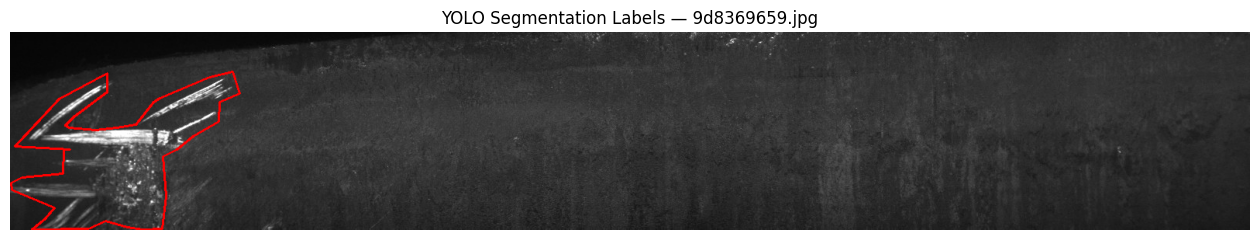

Image: 9d8369659.jpg
YOLO label:
2 0.179375 0.203125 0.160625 0.230469 0.120625 0.335938 0.115625 0.355469 0.101250 0.468750 0.085625 0.488281 0.068750 0.496094 0.047500 0.484375 0.044375 0.476562 0.051250 0.429688 0.078125 0.304688 0.078125 0.210938 0.039375 0.339844 0.003750 0.582031 0.048125 0.593750 0.043125 0.597656 0.042500 0.714844 0.009375 0.734375 0.000625 0.761719 0.001250 0.796875 0.035625 0.886719 0.028125 0.945312 0.017500 0.996094 0.063125 0.992188 0.076875 0.953125 0.094375 0.988281 0.106875 0.996094 0.122500 0.992188 0.125625 0.832031 0.123125 0.632812 0.134375 0.597656 0.148125 0.527344 0.168125 0.453125 0.168750 0.355469 0.185000 0.316406


In [19]:
import cv2
import matplotlib.pyplot as plt
import os
import random

# Pick a training image that has a non-empty label
train_img_dir = "/content/steel_yolo/images/train"
train_label_dir = "/content/steel_yolo/labels/train"

valid_samples = []

for filename in os.listdir(train_img_dir):
    if not filename.endswith(".jpg"):
        continue

    label_file = os.path.join(
        train_label_dir,
        filename.replace(".jpg", ".txt")
    )

    if os.path.exists(label_file) and os.path.getsize(label_file) > 0:
        valid_samples.append(filename)

print("Images with YOLO annotations:", len(valid_samples))

# Pick one
image_name = random.choice(valid_samples)

image_path = os.path.join(train_img_dir, image_name)
label_path = os.path.join(
    train_label_dir,
    image_name.replace(".jpg", ".txt")
)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

# Draw YOLO polygons
with open(label_path, "r") as f:
    lines = f.readlines()

for line in lines:

    values = line.strip().split()

    if len(values) < 7:
        continue

    class_id = int(values[0])

    coords = np.array(
        [float(x) for x in values[1:]],
        dtype=np.float32
    ).reshape(-1, 2)

    # Convert normalized coordinates back to pixels
    coords[:, 0] *= w
    coords[:, 1] *= h

    coords = coords.astype(np.int32)

    cv2.polylines(
        image,
        [coords],
        isClosed=True,
        color=(255, 0, 0),
        thickness=2
    )

plt.figure(figsize=(16, 4))
plt.imshow(image)
plt.title(f"YOLO Segmentation Labels — {image_name}")
plt.axis("off")
plt.show()

print("Image:", image_name)
print("YOLO label:")
print("".join(lines[:5]))

In [20]:
import yaml

data_yaml = {
    "path": "/content/steel_yolo",
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "defect_class_1",
        1: "defect_class_2",
        2: "defect_class_3",
        3: "defect_class_4"
    }
}

yaml_path = "/content/steel_yolo/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(open(yaml_path).read())

path: /content/steel_yolo
train: images/train
val: images/val
names:
  0: defect_class_1
  1: defect_class_2
  2: defect_class_3
  3: defect_class_4



In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")

results = model.train(
    data="/content/steel_yolo/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="/content/steel_runs",
    name="steel_defect_segmentation",
    exist_ok=True
)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/steel_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=steel_defect_segmentation, nbs=64, nms=None, opset=None,

In [22]:
import os

best_model = "/content/steel_runs/steel_defect_segmentation/weights/best.pt"
last_model = "/content/steel_runs/steel_defect_segmentation/weights/last.pt"

print("best.pt exists:", os.path.exists(best_model))
print("last.pt exists:", os.path.exists(last_model))

if os.path.exists(best_model):
    print("best.pt size:", round(os.path.getsize(best_model) / (1024**2), 2), "MB")

best.pt exists: True
last.pt exists: True
best.pt size: 6.19 MB



0: 128x640 1 defect_class_3, 4.5ms
1: 128x640 1 defect_class_3, 1 defect_class_4, 4.5ms
2: 128x640 2 defect_class_3s, 4.5ms
3: 128x640 (no detections), 4.5ms
Speed: 0.6ms preprocess, 4.5ms inference, 3.3ms postprocess per image at shape (1, 3, 128, 640)


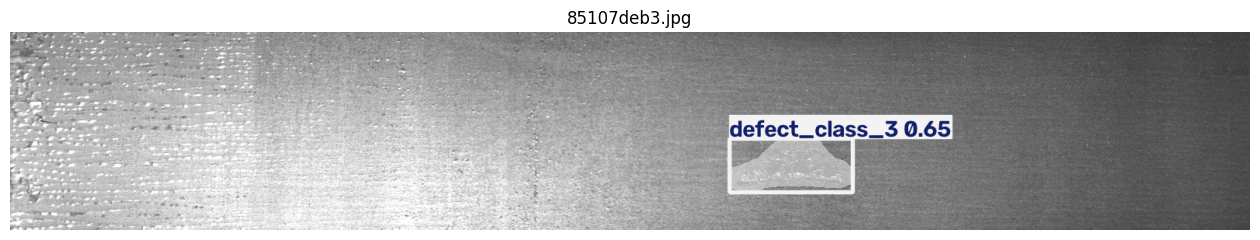

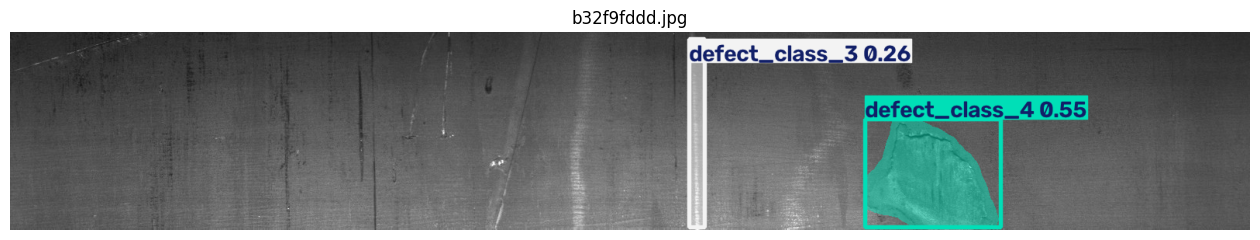

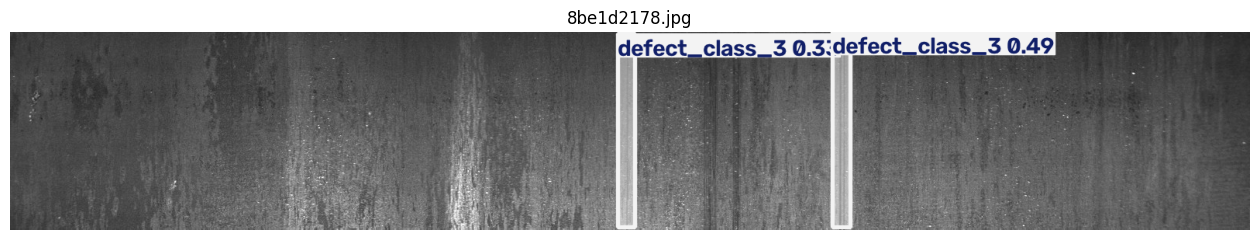

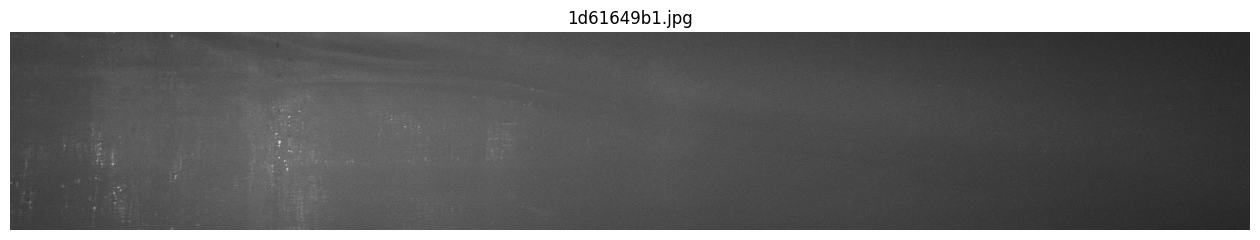

In [23]:
from ultralytics import YOLO
import os
import random
import cv2
import matplotlib.pyplot as plt

# Load trained model
model = YOLO(
    "/content/steel_runs/steel_defect_segmentation/weights/best.pt"
)

# Pick random validation images
val_dir = "/content/steel_yolo/images/val"

images = [
    os.path.join(val_dir, f)
    for f in os.listdir(val_dir)
    if f.endswith(".jpg")
]

random.seed(42)
sample_images = random.sample(images, 4)

# Run prediction
results = model.predict(
    source=sample_images,
    conf=0.25,
    imgsz=640,
    device=0,
    retina_masks=True
)

# Display predictions
for image_path, result in zip(sample_images, results):

    plotted = result.plot()

    plotted = cv2.cvtColor(
        plotted,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(16, 4))
    plt.imshow(plotted)
    plt.title(os.path.basename(image_path))
    plt.axis("off")
    plt.show()

Image: 85107deb3.jpg
Image size: 1600 x 256
Predicted defects: 1
Defect area: 1.85%


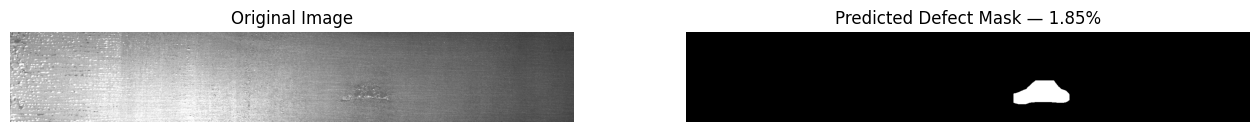

In [24]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

model = YOLO(
    "/content/steel_runs/steel_defect_segmentation/weights/best.pt"
)

# Pick one validation image
image_path = "/content/steel_yolo/images/val/85107deb3.jpg"

result = model.predict(
    source=image_path,
    conf=0.30,
    imgsz=640,
    device=0,
    retina_masks=True,
    verbose=False
)[0]

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

if result.masks is not None:

    # Get predicted masks
    masks = result.masks.data.cpu().numpy()

    # Resize masks to original image size if necessary
    full_masks = []

    for mask in masks:
        mask = cv2.resize(
            mask,
            (w, h),
            interpolation=cv2.INTER_NEAREST
        )
        full_masks.append(mask > 0.5)

    # Combine all predicted defect masks
    combined_mask = np.any(full_masks, axis=0)

    defect_pixels = combined_mask.sum()
    total_pixels = h * w

    defect_area_percentage = (
        defect_pixels / total_pixels
    ) * 100

else:

    combined_mask = np.zeros(
        (h, w),
        dtype=bool
    )

    defect_pixels = 0
    defect_area_percentage = 0


print("Image:", os.path.basename(image_path))
print("Image size:", w, "x", h)
print("Predicted defects:", len(result.masks) if result.masks is not None else 0)
print(f"Defect area: {defect_area_percentage:.2f}%")

# Show mask
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(combined_mask, cmap="gray")
plt.title(f"Predicted Defect Mask — {defect_area_percentage:.2f}%")
plt.axis("off")

plt.show()

In [25]:
# Complete inspection function

from ultralytics import YOLO
import cv2
import numpy as np
import os

model = YOLO(
    "/content/steel_runs/steel_defect_segmentation/weights/best.pt"
)

CLASS_NAMES = {
    0: "Defect Class 1",
    1: "Defect Class 2",
    2: "Defect Class 3",
    3: "Defect Class 4"
}


def inspect_steel_image(image_path, confidence=0.30):

    image = cv2.imread(image_path)

    if image is None:
        raise ValueError("Could not read image.")

    h, w = image.shape[:2]

    result = model.predict(
        source=image_path,
        conf=confidence,
        imgsz=640,
        device=0,
        retina_masks=True,
        verbose=False
    )[0]

    predictions = []

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        combined_mask = np.zeros(
            (h, w),
            dtype=bool
        )

        for i, mask in enumerate(masks):

            mask = cv2.resize(
                mask,
                (w, h),
                interpolation=cv2.INTER_NEAREST
            )

            binary_mask = mask > 0.5

            combined_mask |= binary_mask

            class_id = int(
                result.boxes.cls[i].item()
            )

            confidence_score = float(
                result.boxes.conf[i].item()
            )

            predictions.append({
                "class": CLASS_NAMES[class_id],
                "confidence": confidence_score
            })

        defect_pixels = combined_mask.sum()

    else:

        combined_mask = np.zeros(
            (h, w),
            dtype=bool
        )

        defect_pixels = 0

    total_pixels = h * w

    defect_area = (
        defect_pixels / total_pixels
    ) * 100

    return {
        "image": os.path.basename(image_path),
        "width": w,
        "height": h,
        "defects": predictions,
        "defect_count": len(predictions),
        "defect_area_percent": defect_area,
        "mask": combined_mask
    }


# Test it
result = inspect_steel_image(
    "/content/steel_yolo/images/val/85107deb3.jpg"
)

print("Image:", result["image"])
print("Defect count:", result["defect_count"])
print(f"Defect area: {result['defect_area_percent']:.2f}%")

print("\nPredictions:")

for prediction in result["defects"]:
    print(
        f"- {prediction['class']} | "
        f"confidence: {prediction['confidence']:.2f}"
    )

Image: 85107deb3.jpg
Defect count: 1
Defect area: 1.85%

Predictions:
- Defect Class 3 | confidence: 0.65


In [26]:
from ultralytics import YOLO

model = YOLO(
    "/content/steel_runs/steel_defect_segmentation/weights/best.pt"
)

metrics = model.val(
    data="/content/steel_yolo/data.yaml",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

print("\n--- BOX METRICS ---")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

print("\n--- SEGMENTATION METRICS ---")
print("Precision:", metrics.seg.mp)
print("Recall:", metrics.seg.mr)
print("mAP50:", metrics.seg.map50)
print("mAP50-95:", metrics.seg.map)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 136 layers, 2,689,664 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2194.1±766.6 MB/s, size: 71.0 KB)
val: Scanning /content/steel_yolo/labels/val.cache... 1600 images, 302 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1600/1600 447.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 100/100 6.7it/s 15.0s
                   all       1600       3926      0.485      0.318       0.33      0.151      0.573      0.307      0.299      0.112
        defect_class_1        160        596      0.551       0.22      0.258     0.0863      0.475      0.196      0.187     0.0611
        defect_class_2         46         65      0.533     0.0154      0.113     0.0461          1     0.0306      0.135     0.0453
        defect_class_3       1021

In [27]:
from ultralytics import YOLO
import cv2
import numpy as np
import os

MODEL_PATH = "/content/steel_runs/steel_defect_segmentation/weights/best.pt"

model = YOLO(MODEL_PATH)

CLASS_NAMES = {
    0: "Defect Class 1",
    1: "Defect Class 2",
    2: "Defect Class 3",
    3: "Defect Class 4"
}


def inspect_steel_image(image_path, confidence=0.30):

    image = cv2.imread(image_path)

    if image is None:
        raise ValueError("Could not read image.")

    h, w = image.shape[:2]

    result = model.predict(
        source=image_path,
        conf=confidence,
        imgsz=640,
        device=0,
        retina_masks=True,
        verbose=False
    )[0]

    predictions = []

    combined_mask = np.zeros((h, w), dtype=bool)

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        for i, mask in enumerate(masks):

            mask = cv2.resize(
                mask,
                (w, h),
                interpolation=cv2.INTER_NEAREST
            )

            binary_mask = mask > 0.5

            combined_mask |= binary_mask

            class_id = int(result.boxes.cls[i].item())
            confidence_score = float(result.boxes.conf[i].item())

            predictions.append({
                "class": CLASS_NAMES[class_id],
                "confidence": confidence_score
            })

    defect_pixels = combined_mask.sum()
    total_pixels = h * w

    defect_area = (
        defect_pixels / total_pixels
    ) * 100

    return {
        "image": os.path.basename(image_path),
        "width": w,
        "height": h,
        "defects": predictions,
        "defect_count": len(predictions),
        "defect_area_percent": defect_area,
        "mask": combined_mask
    }

In [28]:
result = inspect_steel_image(
    "/content/steel_yolo/images/val/85107deb3.jpg"
)

print("Image:", result["image"])
print("Defect count:", result["defect_count"])
print(f"Defect area: {result['defect_area_percent']:.2f}%")

print("\nDetected defects:")

for defect in result["defects"]:
    print(
        f"{defect['class']} | "
        f"confidence = {defect['confidence']:.2f}"
    )

Image: 85107deb3.jpg
Defect count: 1
Defect area: 1.85%

Detected defects:
Defect Class 3 | confidence = 0.65


In [29]:
from google.colab import files

files.download(
    "/content/steel_runs/steel_defect_segmentation/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>